# Tugas Lab 2 - Multinomial Naive Bayes

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [14]:
df = pd.read_csv('spam.csv', encoding='latin-1')

df = df.iloc[:, :2]
df.columns = ['Labels', 'SMS']

df.head()

,Labels,SMS
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
print(df.info())
print()
print(df['Labels'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Labels  5572 non-null   object
 1   SMS     5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Labels
ham     4825
spam     747
Name: count, dtype: int64


In [16]:
df['Labels'] = df['Labels'].map({
    'ham': 0,
    'spam': 1
})

X = df['SMS']
y = df['Labels']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=50,
    stratify=y
)

print('Data train:', len(X_train))
print('Data test :', len(X_test))

Data train: 4457
Data test : 1115


## 1. Multinomial Naive Bayes dengan CountVectorizer + Stop Words

In [17]:
count_vectorizer = CountVectorizer(stop_words='english')

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

print('Jumlah fitur:', X_train_count.shape[1])
print('Dimensi data train:', X_train_count.shape)

Jumlah fitur: 7422
Dimensi data train: (4457, 7422)


In [18]:
mnb_count = MultinomialNB()
mnb_count.fit(X_train_count, y_train)

y_pred_count = mnb_count.predict(X_test_count)

acc_count = accuracy_score(y_test, y_pred_count)
prec_count = precision_score(y_test, y_pred_count)
recall_count = recall_score(y_test, y_pred_count)
f1_count = f1_score(y_test, y_pred_count)

print('Accuracy :', acc_count)
print('Precision:', prec_count)
print('Recall   :', recall_count)
print('F1-Score :', f1_count)
print()
print(classification_report(
    y_test,
    y_pred_count,
    target_names=['ham', 'spam']
))

Accuracy : 0.9820627802690582
Precision: 0.9574468085106383
Recall   : 0.9060402684563759
F1-Score : 0.9310344827586207

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.91      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



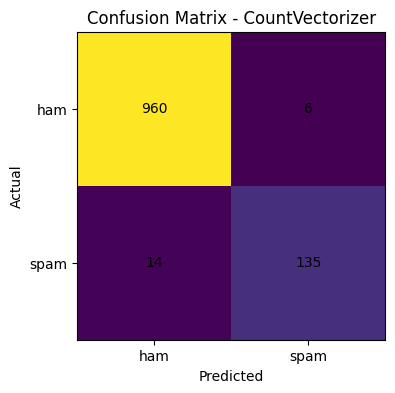

In [19]:
cm_count = confusion_matrix(y_test, y_pred_count)

plt.figure(figsize=(5, 4))
plt.imshow(cm_count)
plt.title('Confusion Matrix - CountVectorizer')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['ham', 'spam'])
plt.yticks([0, 1], ['ham', 'spam'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_count[i, j], ha='center', va='center')

plt.show()

## 2. Multinomial Naive Bayes dengan TF-IDF + Stop Words

In [20]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english')

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print('Jumlah fitur:', X_train_tfidf.shape[1])
print('Dimensi data train:', X_train_tfidf.shape)

Jumlah fitur: 7422
Dimensi data train: (4457, 7422)


In [21]:
mnb_tfidf = MultinomialNB()
mnb_tfidf.fit(X_train_tfidf, y_train)

y_pred_tfidf = mnb_tfidf.predict(X_test_tfidf)

acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
prec_tfidf = precision_score(y_test, y_pred_tfidf)
recall_tfidf = recall_score(y_test, y_pred_tfidf)
f1_tfidf = f1_score(y_test, y_pred_tfidf)

print('Accuracy :', acc_tfidf)
print('Precision:', prec_tfidf)
print('Recall   :', recall_tfidf)
print('F1-Score :', f1_tfidf)
print()
print(classification_report(
    y_test,
    y_pred_tfidf,
    target_names=['ham', 'spam']
))

Accuracy : 0.9730941704035875
Precision: 1.0
Recall   : 0.7986577181208053
F1-Score : 0.8880597014925373

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.80      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



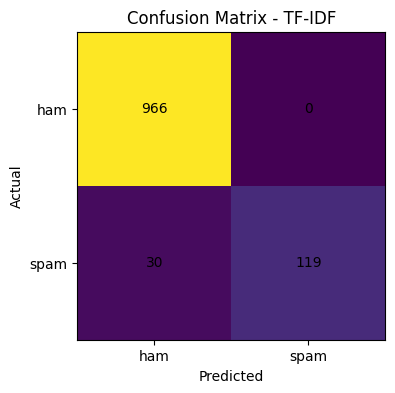

In [22]:
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)

plt.figure(figsize=(5, 4))
plt.imshow(cm_tfidf)
plt.title('Confusion Matrix - TF-IDF')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['ham', 'spam'])
plt.yticks([0, 1], ['ham', 'spam'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_tfidf[i, j], ha='center', va='center')

plt.show()

## 3. Perbandingan Hasil

In [23]:
hasil = pd.DataFrame({
    'Metode': ['CountVectorizer', 'TF-IDF'],
    'Accuracy': [acc_count, acc_tfidf],
    'Precision': [prec_count, prec_tfidf],
    'Recall': [recall_count, recall_tfidf],
    'F1-Score': [f1_count, f1_tfidf]
})

hasil

,Metode,Accuracy,Precision,Recall,F1-Score
0,CountVectorizer,0.982063,0.957447,0.906040,0.931034
1,TF-IDF,0.973094,1.000000,0.798658,0.888060


<Figure size 800x500 with 0 Axes>

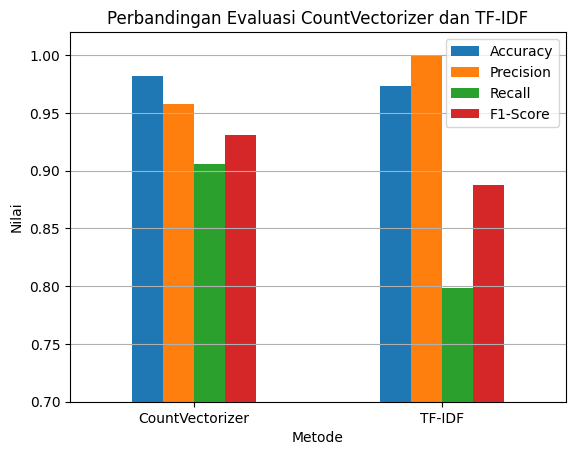

In [24]:
hasil_plot = hasil.set_index('Metode')

plt.figure(figsize=(8, 5))
hasil_plot.plot(kind='bar')
plt.title('Perbandingan Evaluasi CountVectorizer dan TF-IDF')
plt.ylabel('Nilai')
plt.ylim(0.7, 1.02)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

## Kesimpulan

Berdasarkan hasil pengujian pada dataset spam.csv dengan pembagian data yang sama:

- **CountVectorizer + stop words**
  - Accuracy: sekitar **98,21%**
  - Precision spam: sekitar **95,74%**
  - Recall spam: sekitar **90,60%**
  - F1-Score spam: sekitar **93,10%**

- **TF-IDF + stop words**
  - Accuracy: sekitar **97,31%**
  - Precision spam: **100%**
  - Recall spam: sekitar **79,87%**
  - F1-Score spam: sekitar **88,81%**

Pada percobaan ini, CountVectorizer memberikan hasil yang lebih baik secara keseluruhan karena memperoleh accuracy, recall, dan F1-score yang lebih tinggi. TF-IDF memiliki precision spam yang lebih tinggi, tetapi lebih banyak pesan spam yang tidak berhasil terdeteksi sehingga recall-nya lebih rendah.

Dengan demikian, untuk konfigurasi dan pembagian data pada percobaan ini, CountVectorizer lebih optimal untuk klasifikasi spam menggunakan Multinomial Naive Bayes